RAG
- Evaluate embedding model
- Find best embedding model

Method-1
- With ground truth (GT)
- We know what is the right context for a given question 


In [1]:
import pandas as pd
import time
from collections import Counter
import matplotlib.pyplot as plt

import tiktoken
import ollama
from datasets import load_dataset
from langchain_ollama import OllamaEmbeddings
from langchain_community.vectorstores import FAISS

In [2]:
df_rag = load_dataset("neural-bridge/rag-dataset-12000")
df1 = df_rag['train'].to_pandas()
df2 = df_rag['test'].to_pandas()
df_rag = pd.concat([df1, df2], axis=0)
df_rag.head(2)

,context,question,answer
0,Caption: Tasmanian berry grower Nic Hansen sho...,What is the Berry Export Summary 2028 and what...,The Berry Export Summary 2028 is a dedicated e...
1,RWSN Collaborations\nSouthern Africa Self-supp...,What are some of the benefits reported from ha...,Benefits reported from having access to Self-s...


In [26]:
indx = 2
print("Context: \n")
print(df_rag["context"].iloc[indx])

print("\nQuestion: \n")
print(df_rag["question"].iloc[indx])

Context: 

Everybody faces difficult times. For some people, getting help seems impossible. That’s why we have created a program that truly addresses your needs, provides professional care, and inspires you to reach your goals.
Many programs can provide treatment for your condition, but they may not acknowledge or address your deeper spiritual needs. RENEWAL: Christian Treatment and Recovery is a unique program that incorporates your spirituality into your treatment. Our faith-based approach provides an atmosphere of compassion and support that encourages openness, restoration, and healing.
Pastoral counseling, chapel services, and daily devotional readings are just some of the services that set RENEWAL apart from other programs. We invite you to explore our website to learn more about Brookhaven Hospital’s RENEWAL program, and discover how our patients and their families find their way to happier, healthier lives.
Brookhaven Hospital offers proven help for a variety of conditions, inc

In [4]:
def count_tokens(text):
    encoding = tiktoken.get_encoding("cl100k_base")
    tokens = encoding.encode(text)
    return len(tokens)

In [5]:
df_rag['token'] = df_rag['context'].apply(count_tokens)
df_rag.head(2)

,context,question,answer,token
0,Caption: Tasmanian berry grower Nic Hansen sho...,What is the Berry Export Summary 2028 and what...,The Berry Export Summary 2028 is a dedicated e...,678
1,RWSN Collaborations\nSouthern Africa Self-supp...,What are some of the benefits reported from ha...,Benefits reported from having access to Self-s...,943


In [6]:
df_rag = df_rag[~df_rag['question'].isna()]
df_rag = df_rag[df_rag['token'] < 450]
df_rag = df_rag.sample(1000)
len(df_rag)

1000

In [7]:
contexts = list(df_rag["context"])
questions = list(df_rag["question"])

In [8]:
df_rag.to_csv("vector_dbs_1/rag_sample_1000.csv", index=False)

In [9]:
embedding_models = {
    "nomic-embed-text": "nomic",
    "mxbai-embed-large": "mxbai",
    "jina/jina-embeddings-v2-base-en": "jina", 
    "all-minilm:33m": "minilm",
    "snowflake-arctic-embed2": "snowflake",
    "bge-large": "bge",
    "granite-embedding:278m": "granite"
}


In [10]:
# llms = [
#         "nomic-embed-text",
#         "nomic-ai/nomic-embed-text-v1.5",
#         "mxbai-embed-large",
#         "mixedbread-ai/mxbai-embed-large-v1",
#         "jinaai/jina-embeddings-v3",
#         "snowflake-arctic-embed",
#         "Snowflake/snowflake-arctic-embed-l",
#         "sentence-transformers/all-MiniLM-l6-v2",
#         "sentence-transformers/all-MiniLM-l12-v2",
#         "sentence-transformers/all-mpnet-base-v2" 
#         "BAAI/bge-large-en-v1.5",
#         "nvidia/NV-Embed-v2",
#         "Alibaba-NLP/gte-Qwen2-7B-instruct",
#         "Salesforce/SFR-Embedding-2_R"
#         "Alibaba-NLP/gte-large-en-v1.5"
#         "thenlper/gte-large",
#         "intfloat/e5-large-v2",
# ]

In [11]:
results = []

for model, name in embedding_models.items():
    metadata = ollama.show(model)

    nparams = metadata['details']['parameter_size']
    family = metadata['details']['family']
    context_len = metadata['model_info'][family + ".context_length"] 
    emb_size = metadata['model_info'][family + ".embedding_length"]

    results.append({
        "Model Name": name,
        "Model ID": model,
        "Context Length": context_len,
        "Embedding Size": emb_size,
        "Parameter Size": nparams,
        "Family": family
    })

df_models = pd.DataFrame(results)
df_models.head(10)

,Model Name,Model ID,Context Length,Embedding Size,Parameter Size,Family
0,nomic,nomic-embed-text,2048,768,137M,nomic-bert
1,mxbai,mxbai-embed-large,512,1024,334M,bert
2,jina,jina/jina-embeddings-v2-base-en,8192,768,136.78M,jina-bert-v2
3,minilm,all-minilm:33m,512,384,33M,bert
4,snowflake,snowflake-arctic-embed2,8192,1024,566.70M,bert
5,bge,bge-large,512,1024,334.09M,bert
6,granite,granite-embedding:278m,512,768,277.45M,bert


In [12]:
processing_times = []

for llm, name in embedding_models.items():
    ret_docs = []

    llm_embed = OllamaEmbeddings(model=llm)

    start_time = time.time()
    db = FAISS.from_texts(contexts, llm_embed)
    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"Embedding model {name}, Elapsed time: {elapsed_time:.2f} seconds")

    processing_times.append({
        "Model Name": name,
        "Model ID": llm,
        "Processing Time (s)": elapsed_time
    })

    db_name = "vector_dbs_1/" + name
    db.save_local(db_name)


df_times = pd.DataFrame(processing_times)


Embedding model nomic, Elapsed time: 66.26 seconds
Embedding model mxbai, Elapsed time: 159.28 seconds
Embedding model jina, Elapsed time: 62.42 seconds
Embedding model minilm, Elapsed time: 63.12 seconds
Embedding model snowflake, Elapsed time: 188.94 seconds
Embedding model bge, Elapsed time: 111.23 seconds
Embedding model granite, Elapsed time: 72.36 seconds


In [13]:
!ls vector_dbs_1

bge                 jina                mxbai               rag_sample_1000.csv
granite             minilm              nomic               snowflake


In [27]:
!ls vector_dbs_1/bge/

index.faiss index.pkl


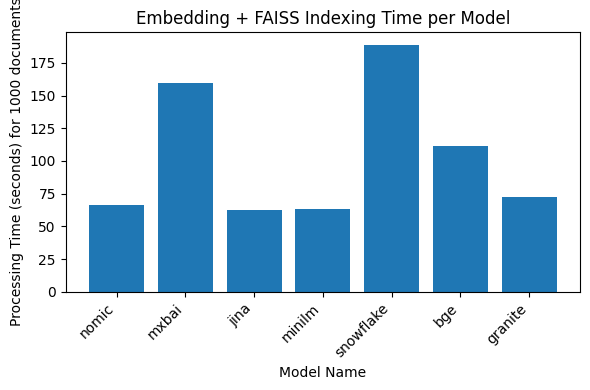

In [15]:
plt.figure(figsize=(6, 4))
plt.bar(df_times['Model Name'], df_times['Processing Time (s)'])
plt.xlabel("Model Name")
plt.ylabel("Processing Time (seconds) for 1000 documents")
plt.title("Embedding + FAISS Indexing Time per Model")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()


In [16]:
df_models.head(10)

,Model Name,Model ID,Context Length,Embedding Size,Parameter Size,Family
0,nomic,nomic-embed-text,2048,768,137M,nomic-bert
1,mxbai,mxbai-embed-large,512,1024,334M,bert
2,jina,jina/jina-embeddings-v2-base-en,8192,768,136.78M,jina-bert-v2
3,minilm,all-minilm:33m,512,384,33M,bert
4,snowflake,snowflake-arctic-embed2,8192,1024,566.70M,bert
5,bge,bge-large,512,1024,334.09M,bert
6,granite,granite-embedding:278m,512,768,277.45M,bert


In [17]:
df_ret = pd.DataFrame()
df_ret['question'] = df_rag['question']
df_ret['context_gt'] = df_rag['context']

processing_times = []

for llm, name in list(embedding_models.items()):
    ret_docs = []
        
    llm_embed = OllamaEmbeddings(model=llm)  
    db_name = "vector_dbs_1/" + name
    db = FAISS.load_local(db_name, llm_embed, allow_dangerous_deserialization=True)
    retriever = db.as_retriever(search_kwargs={"k": 1})
    
    start_time = time.time()
    for que in df_ret['question']:
        ret_doc = retriever.invoke(que)
        ret_doc = ret_doc[0].page_content
        ret_docs.append(ret_doc)
    end_time = time.time()
    elapsed_time = end_time - start_time
    print(f"Embedding model {name}, Elapsed time: {elapsed_time:.2f} seconds")

    processing_times.append({
        "Model Name": name,
        "Model ID": llm,
        "Processing Time (s)": elapsed_time
    })
    df_ret[name] = ret_docs

df_times = pd.DataFrame(processing_times)


Embedding model nomic, Elapsed time: 35.85 seconds
Embedding model mxbai, Elapsed time: 47.24 seconds
Embedding model jina, Elapsed time: 41.38 seconds
Embedding model minilm, Elapsed time: 26.02 seconds
Embedding model snowflake, Elapsed time: 103.52 seconds
Embedding model bge, Elapsed time: 43.93 seconds
Embedding model granite, Elapsed time: 77.51 seconds


In [18]:
df_ret.head()

,question,context_gt,nomic,mxbai,jina,minilm,snowflake,bge,granite
9361,What is the Roo Balls product made from?,"Are you, well, ‘ballsy’ enough for this ‘thund...","Are you, well, ‘ballsy’ enough for this ‘thund...","Are you, well, ‘ballsy’ enough for this ‘thund...",Subtotal: 0.00 PHP\nNo results. Please try som...,"Are you, well, ‘ballsy’ enough for this ‘thund...","Are you, well, ‘ballsy’ enough for this ‘thund...","Are you, well, ‘ballsy’ enough for this ‘thund...","Are you, well, ‘ballsy’ enough for this ‘thund..."
7051,Who is the end user of the new building at Sit...,"- Granta Park, Cambridge\n- Client: BioMed Rea...","- Granta Park, Cambridge\n- Client: BioMed Rea...","- Granta Park, Cambridge\n- Client: BioMed Rea...","- Granta Park, Cambridge\n- Client: BioMed Rea...","- Granta Park, Cambridge\n- Client: BioMed Rea...","- Granta Park, Cambridge\n- Client: BioMed Rea...","- Granta Park, Cambridge\n- Client: BioMed Rea...","- Granta Park, Cambridge\n- Client: BioMed Rea..."
938,What is unique about the RENEWAL program at Br...,Everybody faces difficult times. For some peop...,Everybody faces difficult times. For some peop...,Everybody faces difficult times. For some peop...,Everybody faces difficult times. For some peop...,Everybody faces difficult times. For some peop...,Everybody faces difficult times. For some peop...,Everybody faces difficult times. For some peop...,Everybody faces difficult times. For some peop...
1612,What are the requirements to use Google's Web ...,Google launched a new service called\nGoogle W...,Google launched a new service called\nGoogle W...,Google launched a new service called\nGoogle W...,Google launched a new service called\nGoogle W...,Google launched a new service called\nGoogle W...,Google launched a new service called\nGoogle W...,Google launched a new service called\nGoogle W...,Google launched a new service called\nGoogle W...
6640,When and where is the American Heart Associati...,Missouri News - Page 12\nAn Ode To A Teacher: ...,Missouri News - Page 12\nAn Ode To A Teacher: ...,Missouri News - Page 12\nAn Ode To A Teacher: ...,Events\nEvents\nWe believe that the nonprofit ...,"Here at Amara, we have been brainstorming on h...",Missouri News - Page 12\nAn Ode To A Teacher: ...,Missouri News - Page 12\nAn Ode To A Teacher: ...,Missouri News - Page 12\nAn Ode To A Teacher: ...


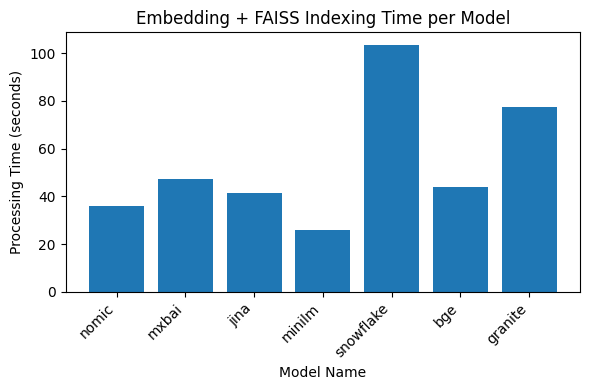

In [19]:
# Plotting
plt.figure(figsize=(6, 4))
plt.bar(df_times['Model Name'], df_times['Processing Time (s)'])
plt.xlabel("Model Name")
plt.ylabel("Processing Time (seconds)")
plt.title("Embedding + FAISS Indexing Time per Model")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()


In [20]:
correct_counts = {}
for model in df_ret.columns[2:]:  
    correct_counts[model] = (df_ret[model] == df_ret['context_gt']).sum()

df_perf = pd.DataFrame(list(correct_counts.items()), columns=['Model', 'Correct_Counts'])
df_perf['Percentage_Correct'] = 100*df_perf['Correct_Counts']/len(df_ret)
df_perf['Percentage_Correct'] = df_perf['Percentage_Correct'].apply(lambda x:round(x,2))

df_perf = df_perf.sort_values(by='Correct_Counts', ascending=False)
df_perf.head(10)

,Model,Correct_Counts,Percentage_Correct
4,snowflake,941,94.1
5,bge,939,93.9
1,mxbai,930,93.0
6,granite,929,92.9
0,nomic,913,91.3
2,jina,908,90.8
3,minilm,874,87.4


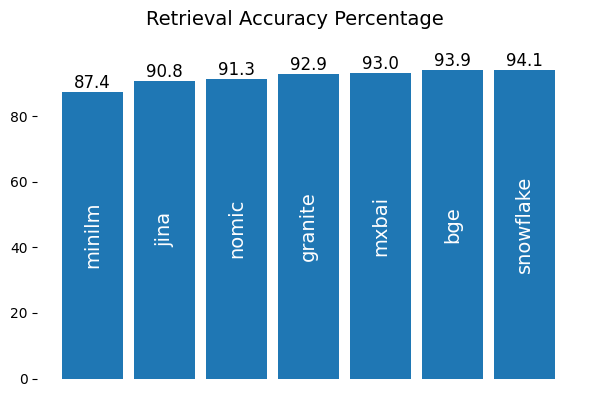

In [21]:
df_perf = df_perf.sort_values('Percentage_Correct', ascending=True)
df_perf = df_perf[df_perf['Percentage_Correct'] != 100.0]


fig, ax = plt.subplots(figsize=(6, 4), facecolor='none', edgecolor='none')
fig.patch.set_alpha(0)

bars = ax.bar(df_perf['Model'], df_perf['Percentage_Correct'], width=0.85)

ax.set_xticks([])  # Hide tick marks

# Remove all spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Value label to the right of the bar
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height, f'{height}', 
            ha='center', va='bottom', fontsize=12, color='black')

# Model label inside the bar
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height / 2, df_perf['Model'].iloc[i], 
            ha='center', va='center', fontsize=14, color='white', rotation=90)

ax.set_ylabel('')
ax.patch.set_alpha(0)

plt.suptitle("Retrieval Accuracy Percentage", fontsize=14)
plt.tight_layout()
#plt.savefig('retrieval_accuracy_wit_gt.png', dpi=300, bbox_inches='tight', transparent=True)



In [22]:
df_models.head(10)

,Model Name,Model ID,Context Length,Embedding Size,Parameter Size,Family
0,nomic,nomic-embed-text,2048,768,137M,nomic-bert
1,mxbai,mxbai-embed-large,512,1024,334M,bert
2,jina,jina/jina-embeddings-v2-base-en,8192,768,136.78M,jina-bert-v2
3,minilm,all-minilm:33m,512,384,33M,bert
4,snowflake,snowflake-arctic-embed2,8192,1024,566.70M,bert
5,bge,bge-large,512,1024,334.09M,bert
6,granite,granite-embedding:278m,512,768,277.45M,bert


In [23]:
exit("Stop here....")